In [1]:
# === Import thư viện ===
import os
import pandas as pd
import mne
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
import gc

In [2]:
# === Config ===
raw_dir = "../data/raw"
out_dir = "../data/processed_tensor_4s_cwt"
participants_file = os.path.join(raw_dir, "participants.tsv")

os.makedirs(out_dir, exist_ok=True)

# Thông số phân đoạn
segment_length_sec = 4
sampling_rate = 500
segment_length = segment_length_sec * sampling_rate
overlap_ratio = 0.5
overlap_step = int(segment_length * (1 - overlap_ratio))

# Thông số CWT - TỐI ƯU CHO ALZHEIMER/FTD
CWT_FREQ_MIN = 0.5        # Hz - bắt đầu từ Delta thấp
CWT_FREQ_MAX = 45         # Hz - đến mid-Gamma
CWT_N_FREQS = 65          # Độ phân giải ~0.5 Hz/step
WAVELET_WIDTH = 6         # Morlet wavelet width chuẩn

In [3]:
# === Load participants metadata ===
participants_df = pd.read_csv(participants_file, sep="\t")
participants_df = participants_df[["participant_id", "Group"]]
group_mapping = participants_df.set_index("participant_id")["Group"].to_dict()

In [4]:
import pywt

def compute_cwt_spectrogram(signal_1d, fs):
    """
    CWT spectrogram tối ưu cho phân loại Alzheimer/FTD
    Sử dụng PyWavelets thay vì scipy.signal
    """
    # Tạo dải tần số tuyến tính
    freqs = np.linspace(CWT_FREQ_MIN, CWT_FREQ_MAX, CWT_N_FREQS)
    
    # Chuyển sang scales cho Morlet wavelet
    # Với pywt, công thức: scale = (center_freq * fs) / freq
    # Morlet có center frequency mặc định = 1.0
    scales = (1.0 * fs) / freqs
    
    # Tính CWT với Morlet wavelet ('morl')
    # coeffs shape: (n_scales, signal_length)
    coeffs, _ = pywt.cwt(signal_1d, scales, 'morl', sampling_period=1/fs)
    
    # Tính power và chuyển sang dB
    Sxx = np.abs(coeffs) ** 2
    Sxx = 10 * np.log10(Sxx + 1e-8)
    
    return Sxx.astype(np.float32)  # (80, T) ~ (Freqs, Time)

In [5]:
# ==== Lặp toàn bộ subjects ====
from skimage.transform import resize
for subj in participants_df["participant_id"]:
    subj_dir = os.path.join(raw_dir, subj, "eeg")
    eeg_file = os.path.join(subj_dir, f"{subj}_task-photomark_eeg.set")

    if not os.path.exists(eeg_file):
        print(f"⚠️ File EEG không tồn tại: {subj}")
        continue

    print(f"🔹 Loading {subj} ...")
    raw = mne.io.read_raw_eeglab(eeg_file, preload=True)
    data = raw.get_data()  # (n_channels, n_samples)
    n_channels, n_samples = data.shape

    label = group_mapping.get(subj, "Unknown")

    # ==== Chọn overlap riêng cho lớp F ====
    if label == "F":
        overlap_ratio = 0.75   # overlap lớn hơn → nhiều segment hơn
    else:
        overlap_ratio = 0.5
    overlap_step = int(segment_length * (1 - overlap_ratio))

    # ==== Sliding window segmentation ====
    seg_id = 0
    start = 0
    while start + segment_length <= n_samples:
        segment = data[:, start:start + segment_length]

        # Tính spectrogram cho từng kênh
        specs = []
        for ch_idx in range(n_channels):
            Sxx = compute_cwt_spectrogram(segment[ch_idx], sampling_rate)  # (F, T)
            # Resize về (65, 224)
            Sxx_resized = resize(
                Sxx,
                (65, 224),
                order=3,    # cubic interpolation – dùng cho dữ liệu EEG tốt nhất
                mode='reflect',
                anti_aliasing=True
            ).astype(np.float32)
            
            specs.append(Sxx_resized)

        # Stack thành tensor (n_channels, F, T)
        tensor = np.stack(specs, axis=0).astype(np.float32)

        # Lưu tensor
        out_subdir = os.path.join(out_dir, label)
        os.makedirs(out_subdir, exist_ok=True)
        out_file = os.path.join(out_subdir, f"{subj}_segment{seg_id:04d}.npy")
        np.save(out_file, tensor)

        seg_id += 1
        start += overlap_step

    del raw
    gc.collect()

    print(f" ✅ {subj}: {seg_id} segments saved (tensor shape {tensor.shape}).")

print("=== DONE ===")

🔹 Loading sub-001 ...


C:\Users\NANG TIEN HANH\AppData\Local\Temp\ipykernel_14412\2158386263.py:12: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(eeg_file, preload=True)


 ✅ sub-001: 150 segments saved (tensor shape (19, 65, 224)).
🔹 Loading sub-002 ...


C:\Users\NANG TIEN HANH\AppData\Local\Temp\ipykernel_14412\2158386263.py:12: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(eeg_file, preload=True)


 ✅ sub-002: 192 segments saved (tensor shape (19, 65, 224)).
🔹 Loading sub-003 ...


...

 ✅ sub-086: 74 segments saved (tensor shape (19, 65, 224)).
🔹 Loading sub-087 ...


C:\Users\NANG TIEN HANH\AppData\Local\Temp\ipykernel_14412\2158386263.py:12: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(eeg_file, preload=True)
C:\Users\NANG TIEN HANH\AppData\Local\Temp\ipykernel_14412\2158386263.py:12: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(eeg_file, preload=True)


 ✅ sub-087: 71 segments saved (tensor shape (19, 65, 224)).
🔹 Loading sub-088 ...


C:\Users\NANG TIEN HANH\AppData\Local\Temp\ipykernel_14412\2158386263.py:12: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(eeg_file, preload=True)


 ✅ sub-088: 124 segments saved (tensor shape (19, 65, 224)).
=== DONE ===


Tensor shape: (19, 65, 224)


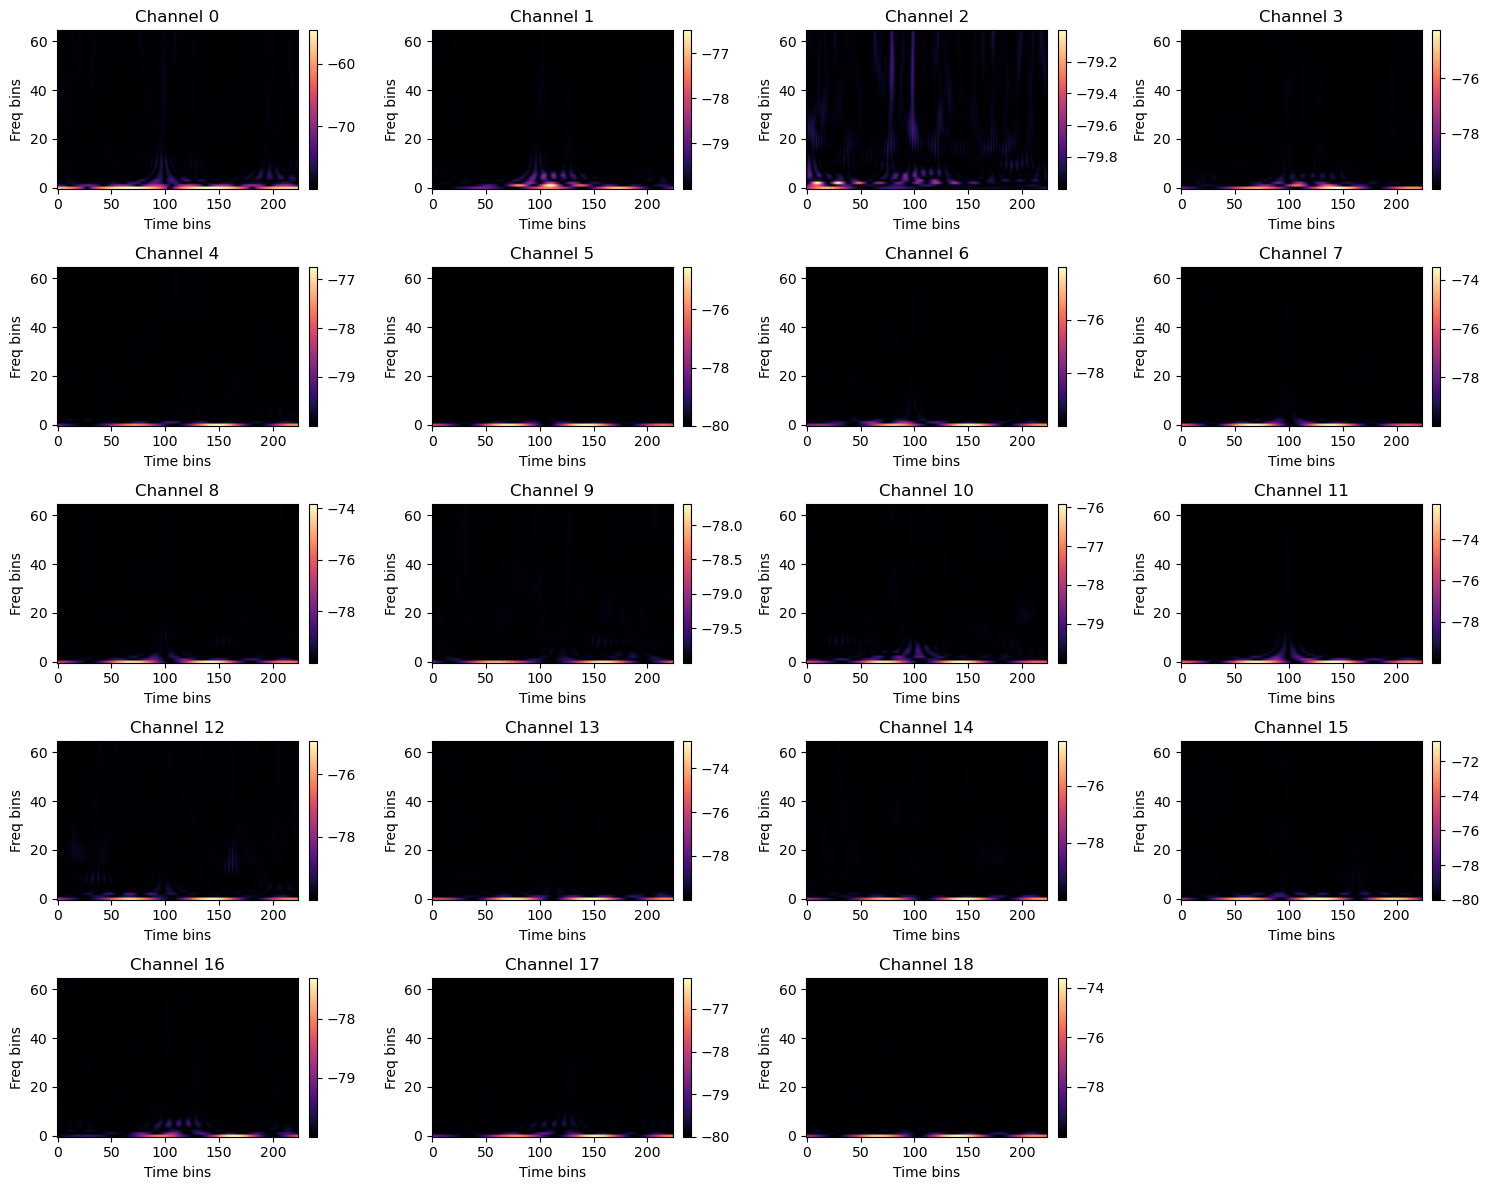

In [9]:
# ================== Test Load & Visualize ==================
tensor_file = "../data/processed_tensor_4s_cwt/F/sub-066_segment0001.npy"

if os.path.exists(tensor_file):
    specs = np.load(tensor_file)   # (19, F, T)
    print("Tensor shape:", specs.shape)

    n_channels = specs.shape[0]

    # Sắp xếp grid: 19 kênh -> 5 hàng x 4 cột (còn dư 1 ô trống)
    n_rows = 5
    n_cols = 4

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))
    axes = axes.flatten()

    for ch in range(n_channels):
        im = axes[ch].imshow(specs[ch], aspect="auto", origin="lower", cmap="magma")
        axes[ch].set_title(f"Channel {ch}")
        axes[ch].set_xlabel("Time bins")
        axes[ch].set_ylabel("Freq bins")
        fig.colorbar(im, ax=axes[ch], fraction=0.046, pad=0.04)

    # Ẩn subplot thừa nếu có
    for ax in axes[n_channels:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ File test không tồn tại:", tensor_file)